# Bengaluru Strategic Logistics Optimizer (BSLO)
## Part 2: Baseline Modeling

**Author:** [Your Name]  
**Date:** February 2026  

---

### Objective
Build a baseline regression model to predict **Congestion Level** using the cleaned traffic dataset. This notebook establishes a performance baseline using DummyRegressor before implementing more sophisticated models.

### Table of Contents
1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Feature Preparation](#2-feature-preparation)
3. [Train-Test Split (Temporal)](#3-train-test-split-temporal)
4. [Preprocessing Pipeline](#4-preprocessing-pipeline)
5. [Baseline Model](#5-baseline-model)
6. [Model Evaluation](#6-model-evaluation)
7. [Summary and Next Steps](#7-summary-and-next-steps)

---
## 1. Setup and Data Loading <a id='1-setup-and-data-loading'></a>

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Baseline model
from sklearn.dummy import DummyRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# Random seed for reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load cleaned dataset
DATA_PATH = '../data/traffic_data_cleaned.csv'
df = pd.read_csv(DATA_PATH)

# Convert Date back to datetime
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")

Dataset loaded successfully!
Shape: 8,824 rows × 37 columns
Date range: 2022-01-08 to 2024-08-09


In [3]:
# Quick data inspection
df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,Year,Month,Day_of_Week,Day_Name,Is_Weekend,Quarter,Day_of_Month,Traffic Volume_Lag1,Traffic Volume_Lag7,Traffic Volume_Rolling7,Congestion Level_Lag1,Congestion Level_Lag7,Congestion Level_Rolling7,Average Speed_Lag1,Average Speed_Lag7,Average Speed_Rolling7,Speed_Volume_Ratio,Congestion_per_Incident,Road_Avg_Congestion,Area_Avg_Congestion,Congestion_Deviation
0,2022-01-08,Indiranagar,100 Feet Road,36384,28.1895,1.5000,100.0000,100.0000,2,122.7680,15.0713,75.6997,73.9969,103,Rain,No,2022,1,5,Saturday,1,1,8,24405.0000,50590.0000,37601.2857,82.9517,100.0000,92.6548,29.8426,50.2303,44.3480,0.7748,33.3333,87.1074,87.6419,12.8926
1,2022-01-10,Indiranagar,100 Feet Road,43024,28.0709,1.5000,100.0000,100.0000,3,136.0480,53.6702,78.0707,79.3304,89,Overcast,No,2022,1,0,Monday,0,1,10,36384.0000,22050.0000,35571.8571,100.0000,78.4298,92.6548,28.1895,52.8708,41.1993,0.6524,25.0000,87.1074,87.6419,12.8926
2,2022-01-11,Indiranagar,100 Feet Road,11423,20.0000,1.0077,33.2729,59.7179,0,72.8460,47.4717,68.6081,50.6060,199,Clear,No,2022,1,1,Tuesday,0,1,11,43024.0000,23457.0000,38568.1429,100.0000,87.2021,95.7363,28.0709,38.8691,37.6565,1.7509,33.2729,87.1074,87.6419,-53.8345
3,2022-01-13,Indiranagar,100 Feet Road,11371,51.0248,1.1034,31.1975,55.1572,1,72.7420,24.3417,95.1132,93.9791,218,Clear,No,2022,1,3,Thursday,0,1,13,11423.0000,46199.0000,36849.0000,33.2729,100.0000,88.0321,20.0000,41.2285,34.9609,4.4873,15.5987,87.1074,87.6419,-55.9100
4,2022-01-14,Indiranagar,100 Feet Road,24545,51.5038,1.2242,74.0365,100.0000,3,99.0900,78.3760,64.4288,71.1274,117,Overcast,No,2022,1,4,Friday,0,1,14,11371.0000,49952.0000,31873.5714,31.1975,100.0000,78.2032,51.0248,50.8013,36.3603,2.0983,18.5091,87.1074,87.6419,-13.0710


In [4]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8824 entries, 0 to 8823
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Date                                8824 non-null   datetime64[ns]
 1   Area Name                           8824 non-null   object        
 2   Road/Intersection Name              8824 non-null   object        
 3   Traffic Volume                      8824 non-null   int64         
 4   Average Speed                       8824 non-null   float64       
 5   Travel Time Index                   8824 non-null   float64       
 6   Congestion Level                    8824 non-null   float64       
 7   Road Capacity Utilization           8824 non-null   float64       
 8   Incident Reports                    8824 non-null   int64         
 9   Environmental Impact                8824 non-null   float64       
 10  Public Transport Usage  

---
## 2. Feature Preparation <a id='2-feature-preparation'></a>

In [5]:
# Define target variable
TARGET = 'Congestion Level'

# Define features to exclude (targets, identifiers, derived from target)
EXCLUDE_FEATURES = [
    'Date',  # Will use temporal features instead
    'Congestion Level',  # Target variable
    'Environmental Impact',  # Alternative target
    'Average Speed',  # Highly correlated with target
    'Travel Time Index',  # Highly correlated with target
    'Day_Name',  # Use Day_of_Week instead
    'Year',  # Not useful for prediction (limited range)
    # Derived features that leak target information
    'Road_Avg_Congestion',
    'Area_Avg_Congestion',
    'Congestion_Deviation',
    'Congestion_per_Incident',
    # Lag features of target (we'll keep these for now but can remove if needed)
    # 'Congestion Level_Lag1',
    # 'Congestion Level_Lag7',
    # 'Congestion Level_Rolling7',
]

print(f"Target variable: {TARGET}")
print(f"Features to exclude: {len(EXCLUDE_FEATURES)}")

Target variable: Congestion Level
Features to exclude: 11


In [6]:
# Separate features and target
X = df.drop(columns=EXCLUDE_FEATURES)
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget statistics:")
print(y.describe())

Feature matrix shape: (8824, 26)
Target shape: (8824,)

Target statistics:
count   8824.0000
mean      80.8554
std       23.5128
min        5.1603
25%       64.3567
50%       92.4246
75%      100.0000
max      100.0000
Name: Congestion Level, dtype: float64


In [7]:
# Identify categorical and numerical columns
categorical_features = ['Area Name', 'Road/Intersection Name', 'Weather Conditions', 
                        'Roadwork and Construction Activity']

# All other columns are numerical
numerical_features = [col for col in X.columns if col not in categorical_features]

print(f"Categorical features ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"  - {feat}")

print(f"\nNumerical features ({len(numerical_features)}):")
for feat in numerical_features:
    print(f"  - {feat}")

Categorical features (4):
  - Area Name
  - Road/Intersection Name
  - Weather Conditions
  - Roadwork and Construction Activity

Numerical features (22):
  - Traffic Volume
  - Road Capacity Utilization
  - Incident Reports
  - Public Transport Usage
  - Traffic Signal Compliance
  - Parking Usage
  - Pedestrian and Cyclist Count
  - Month
  - Day_of_Week
  - Is_Weekend
  - Quarter
  - Day_of_Month
  - Traffic Volume_Lag1
  - Traffic Volume_Lag7
  - Traffic Volume_Rolling7
  - Congestion Level_Lag1
  - Congestion Level_Lag7
  - Congestion Level_Rolling7
  - Average Speed_Lag1
  - Average Speed_Lag7
  - Average Speed_Rolling7
  - Speed_Volume_Ratio


---
## 3. Train-Test Split (Temporal) <a id='3-train-test-split-temporal'></a>

For time-series data, we use a **temporal split** where training data comes from earlier dates and test data from later dates. This prevents data leakage and simulates real-world prediction scenarios.

In [8]:
# Sort by date to ensure temporal ordering
df_sorted = df.sort_values('Date').reset_index(drop=True)
X_sorted = df_sorted.drop(columns=EXCLUDE_FEATURES)
y_sorted = df_sorted[TARGET]
dates_sorted = df_sorted['Date']

# Calculate split index (70% train, 30% test)
test_size = 0.3
split_idx = int(len(df_sorted) * (1 - test_size))

# Temporal split
X_train = X_sorted.iloc[:split_idx]
X_test = X_sorted.iloc[split_idx:]
y_train = y_sorted.iloc[:split_idx]
y_test = y_sorted.iloc[split_idx:]
dates_train = dates_sorted.iloc[:split_idx]
dates_test = dates_sorted.iloc[split_idx:]

print("=" * 60)
print("TEMPORAL TRAIN-TEST SPLIT")
print("=" * 60)
print(f"Total samples: {len(df_sorted):,}")
print(f"\nTraining set:")
print(f"  - Samples: {len(X_train):,} ({len(X_train)/len(df_sorted)*100:.1f}%)")
print(f"  - Date range: {dates_train.min().strftime('%Y-%m-%d')} to {dates_train.max().strftime('%Y-%m-%d')}")
print(f"  - Target mean: {y_train.mean():.2f}")
print(f"  - Target std: {y_train.std():.2f}")
print(f"\nTest set:")
print(f"  - Samples: {len(X_test):,} ({len(X_test)/len(df_sorted)*100:.1f}%)")
print(f"  - Date range: {dates_test.min().strftime('%Y-%m-%d')} to {dates_test.max().strftime('%Y-%m-%d')}")
print(f"  - Target mean: {y_test.mean():.2f}")
print(f"  - Target std: {y_test.std():.2f}")
print("=" * 60)

TEMPORAL TRAIN-TEST SPLIT
Total samples: 8,824

Training set:
  - Samples: 6,176 (70.0%)
  - Date range: 2022-01-08 to 2023-11-03
  - Target mean: 80.82
  - Target std: 23.52

Test set:
  - Samples: 2,648 (30.0%)
  - Date range: 2023-11-03 to 2024-08-09
  - Target mean: 80.93
  - Target std: 23.49


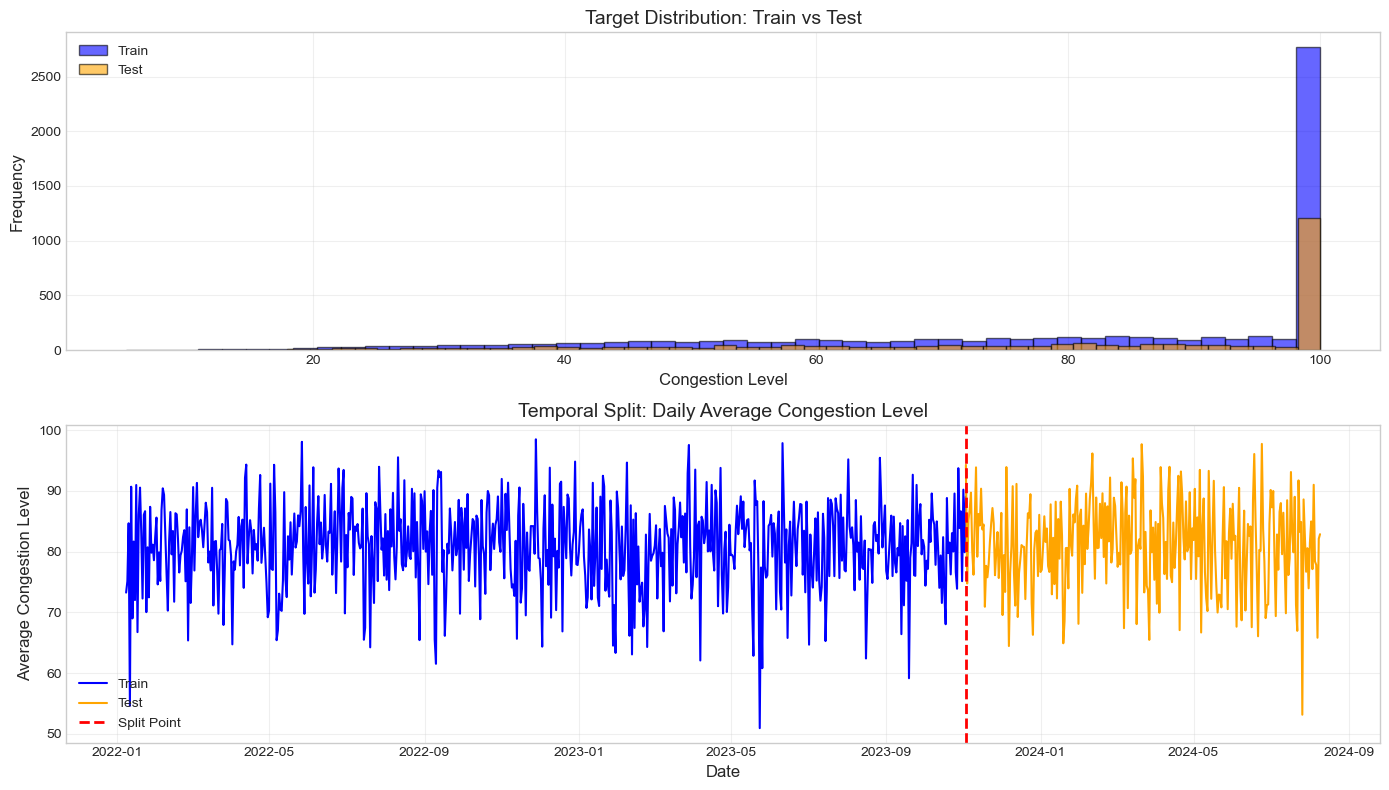

In [9]:
# Visualize train-test split
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Target distribution in train vs test
axes[0].hist(y_train, bins=50, alpha=0.6, label='Train', color='blue', edgecolor='black')
axes[0].hist(y_test, bins=50, alpha=0.6, label='Test', color='orange', edgecolor='black')
axes[0].set_title('Target Distribution: Train vs Test', fontsize=14)
axes[0].set_xlabel('Congestion Level', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Temporal split visualization
train_avg = df_sorted.iloc[:split_idx].groupby('Date')[TARGET].mean()
test_avg = df_sorted.iloc[split_idx:].groupby('Date')[TARGET].mean()

axes[1].plot(train_avg.index, train_avg.values, label='Train', color='blue', linewidth=1.5)
axes[1].plot(test_avg.index, test_avg.values, label='Test', color='orange', linewidth=1.5)
axes[1].axvline(x=dates_train.max(), color='red', linestyle='--', linewidth=2, label='Split Point')
axes[1].set_title('Temporal Split: Daily Average Congestion Level', fontsize=14)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Average Congestion Level', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Preprocessing Pipeline <a id='4-preprocessing-pipeline'></a>

We'll create a preprocessing pipeline using:
- **StandardScaler** for numerical features (z-score normalization)
- **OneHotEncoder** for categorical features

In [10]:
# Create preprocessing pipelines for numerical and categorical features

# Numerical pipeline: StandardScaler (z-score normalization)
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline: OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'  # Drop any columns not specified
)

print("Preprocessing pipeline created:")
print(f"  - Numerical features: StandardScaler")
print(f"  - Categorical features: OneHotEncoder (drop_first=True)")
print(f"\nPreprocessor:")
print(preprocessor)

Preprocessing pipeline created:
  - Numerical features: StandardScaler
  - Categorical features: OneHotEncoder (drop_first=True)

Preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Traffic Volume', 'Road Capacity Utilization',
                                  'Incident Reports', 'Public Transport Usage',
                                  'Traffic Signal Compliance', 'Parking Usage',
                                  'Pedestrian and Cyclist Count', 'Month',
                                  'Day_of_Week', 'Is_Weekend', 'Quarter',
                                  'Day_of_Month', 'Traffic Volume_Lag1',
                                  'Traffic Volume_Lag7',
                                  'Traffic Vo...
                                  'Congestion Level_Lag1',
                                  'Congestion Level_Lag7',
                                  'Congestion Le

In [11]:
# Fit preprocessor on training data ONLY
print("Fitting preprocessor on training data...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nTraining data shape after preprocessing: {X_train_processed.shape}")
print(f"Test data shape after preprocessing: {X_test_processed.shape}")

# Get feature names after preprocessing
feature_names_out = []

# Numerical features keep their names
feature_names_out.extend(numerical_features)

# Categorical features get encoded names
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names_out.extend(cat_feature_names)

print(f"\nTotal features after preprocessing: {len(feature_names_out)}")
print(f"  - Original numerical: {len(numerical_features)}")
print(f"  - One-hot encoded categorical: {len(cat_feature_names)}")

Fitting preprocessor on training data...

Training data shape after preprocessing: (6176, 49)
Test data shape after preprocessing: (2648, 49)

Total features after preprocessing: 49
  - Original numerical: 22
  - One-hot encoded categorical: 27


In [12]:
# Convert to DataFrame for easier inspection
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names_out, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names_out, index=X_test.index)

print("Preprocessed training data (first 5 rows):")
X_train_df.head()

Preprocessed training data (first 5 rows):


,Traffic Volume,Road Capacity Utilization,Incident Reports,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Month,Day_of_Week,Is_Weekend,Quarter,Day_of_Month,Traffic Volume_Lag1,Traffic Volume_Lag7,Traffic Volume_Rolling7,Congestion Level_Lag1,Congestion Level_Lag7,Congestion Level_Rolling7,Average Speed_Lag1,Average Speed_Lag7,Average Speed_Rolling7,Speed_Volume_Ratio,Area Name_Hebbal,Area Name_Indiranagar,Area Name_Jayanagar,Area Name_Koramangala,Area Name_M.G. Road,Area Name_Whitefield,Area Name_Yeshwanthpur,Road/Intersection Name_Anil Kumble Circle,Road/Intersection Name_Ballari Road,Road/Intersection Name_CMH Road,Road/Intersection Name_Hebbal Flyover,Road/Intersection Name_Hosur Road,Road/Intersection Name_ITPL Main Road,Road/Intersection Name_Jayanagar 4th Block,Road/Intersection Name_Marathahalli Bridge,Road/Intersection Name_Sarjapur Road,Road/Intersection Name_Silk Board Junction,Road/Intersection Name_Sony World Junction,Road/Intersection Name_South End Circle,Road/Intersection Name_Trinity Circle,Road/Intersection Name_Tumkur Road,Road/Intersection Name_Yeshwanthpur Circle,Weather Conditions_Fog,Weather Conditions_Overcast,Weather Conditions_Rain,Weather Conditions_Windy,Roadwork and Construction Activity_Yes
0,0.5398,0.4784,0.2914,-1.4917,-0.3602,-0.0913,-0.3117,-1.6277,1.0010,1.5828,-1.3233,-0.8952,-0.3753,1.6226,0.9620,0.0894,0.8150,0.8497,-0.8950,1.0078,1.0710,-0.7401,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
1,-1.3960,-2.4498,-1.1036,0.3948,0.7114,0.1869,2.3475,-1.6277,1.0010,1.5828,-1.3233,-0.8952,-0.2712,0.1147,0.6796,0.2111,0.8150,0.9307,-1.3007,-0.9384,-1.7927,1.5611,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
2,0.7204,0.4784,0.2914,-1.6386,-0.6526,0.6931,-0.6645,-1.6277,1.4995,1.5828,-1.3233,-0.7818,-1.3969,0.6527,0.3510,-1.4611,0.8150,0.3814,0.4743,-1.2136,-1.3219,-0.5863,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
3,-1.1769,-1.4330,-1.1036,-0.9210,-0.4267,-0.9732,1.6148,-1.6277,1.4995,1.5828,-1.3233,-0.7818,2.7467,2.1339,1.3486,0.8148,0.8150,1.2383,-0.2296,0.1573,-0.6002,0.2664,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
4,1.0469,0.4784,0.9889,0.4145,-0.1553,0.2810,-0.6916,-1.6277,-1.4920,-0.6318,-1.3233,-0.6684,0.5399,-0.5547,0.7261,0.8148,-0.1008,0.8497,-1.0492,1.2542,0.3860,-0.8264,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000


In [13]:
# Verify StandardScaler worked (mean ≈ 0, std ≈ 1 for numerical features)
print("Verification: Numerical features after StandardScaler")
print("=" * 60)
numerical_stats = X_train_df[numerical_features].describe().T[['mean', 'std']]
print(numerical_stats)
print("\nNote: Mean should be ≈ 0 and Std should be ≈ 1")

Verification: Numerical features after StandardScaler
                                mean    std
Traffic Volume                0.0000 1.0001
Road Capacity Utilization    -0.0000 1.0001
Incident Reports             -0.0000 1.0001
Public Transport Usage       -0.0000 1.0001
Traffic Signal Compliance    -0.0000 1.0001
Parking Usage                 0.0000 1.0001
Pedestrian and Cyclist Count -0.0000 1.0001
Month                        -0.0000 1.0001
Day_of_Week                   0.0000 1.0001
Is_Weekend                   -0.0000 1.0001
Quarter                      -0.0000 1.0001
Day_of_Month                  0.0000 1.0001
Traffic Volume_Lag1          -0.0000 1.0001
Traffic Volume_Lag7           0.0000 1.0001
Traffic Volume_Rolling7      -0.0000 1.0001
Congestion Level_Lag1        -0.0000 1.0001
Congestion Level_Lag7         0.0000 1.0001
Congestion Level_Rolling7    -0.0000 1.0001
Average Speed_Lag1           -0.0000 1.0001
Average Speed_Lag7           -0.0000 1.0001
Average Speed_Rolling7

---
## 5. Baseline Model <a id='5-baseline-model'></a>

We'll use **DummyRegressor** as our baseline model. This provides a simple benchmark that more sophisticated models should beat.

**Strategies:**
- **mean**: Predicts the mean of the training target
- **median**: Predicts the median of the training target
- **quantile**: Predicts a specified quantile
- **constant**: Predicts a constant value

We'll use the **mean** strategy as it's the most common baseline for regression.

In [14]:
# Create baseline model
baseline_model = DummyRegressor(strategy='mean')

print("Baseline Model: DummyRegressor")
print(f"Strategy: mean")
print(f"\nThis model will predict the training set mean ({y_train.mean():.2f}) for all test samples.")

Baseline Model: DummyRegressor
Strategy: mean

This model will predict the training set mean (80.82) for all test samples.


In [15]:
# Fit baseline model on training data
print("Fitting baseline model...")
baseline_model.fit(X_train_processed, y_train)
print("✓ Baseline model fitted successfully!")

# Make predictions
y_train_pred_baseline = baseline_model.predict(X_train_processed)
y_test_pred_baseline = baseline_model.predict(X_test_processed)

print(f"\nPredictions generated:")
print(f"  - Training predictions: {len(y_train_pred_baseline):,}")
print(f"  - Test predictions: {len(y_test_pred_baseline):,}")
print(f"\nAll predictions are: {y_test_pred_baseline[0]:.2f} (training mean)")

Fitting baseline model...
✓ Baseline model fitted successfully!

Predictions generated:
  - Training predictions: 6,176
  - Test predictions: 2,648

All predictions are: 80.82 (training mean)


---
## 6. Model Evaluation <a id='6-model-evaluation'></a>

We'll evaluate the baseline model using standard regression metrics:
- **RMSE** (Root Mean Squared Error): Lower is better, penalizes large errors
- **MAE** (Mean Absolute Error): Lower is better, average absolute error
- **R² Score**: Higher is better (max 1.0), proportion of variance explained

In [16]:
def evaluate_model(y_true, y_pred, dataset_name=''):
    """
    Calculate and display regression metrics.
    
    Parameters:
    -----------
    y_true : array-like
        True target values
    y_pred : array-like
        Predicted target values
    dataset_name : str
        Name of the dataset (e.g., 'Train', 'Test')
    
    Returns:
    --------
    dict : Dictionary containing all metrics
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    metrics = {
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2
    }
    
    print(f"{dataset_name} Metrics:")
    print("-" * 40)
    print(f"  RMSE:     {rmse:.4f}")
    print(f"  MAE:      {mae:.4f}")
    print(f"  R² Score: {r2:.4f}")
    print()
    
    return metrics

In [17]:
# Evaluate baseline model
print("=" * 60)
print("BASELINE MODEL EVALUATION")
print("=" * 60)
print()

train_metrics = evaluate_model(y_train, y_train_pred_baseline, 'Training')
test_metrics = evaluate_model(y_test, y_test_pred_baseline, 'Test')

print("=" * 60)

BASELINE MODEL EVALUATION

Training Metrics:
----------------------------------------
  RMSE:     23.5213
  MAE:      19.9625
  R² Score: 0.0000

Test Metrics:
----------------------------------------
  RMSE:     23.4886
  MAE:      19.9626
  R² Score: -0.0000



In [18]:
# Create comparison DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R² Score'],
    'Train': [train_metrics['RMSE'], train_metrics['MAE'], train_metrics['R² Score']],
    'Test': [test_metrics['RMSE'], test_metrics['MAE'], test_metrics['R² Score']]
})

print("\nBaseline Model Performance Summary:")
print(metrics_df.to_string(index=False))


Baseline Model Performance Summary:
  Metric   Train    Test
    RMSE 23.5213 23.4886
     MAE 19.9625 19.9626
R² Score  0.0000 -0.0000


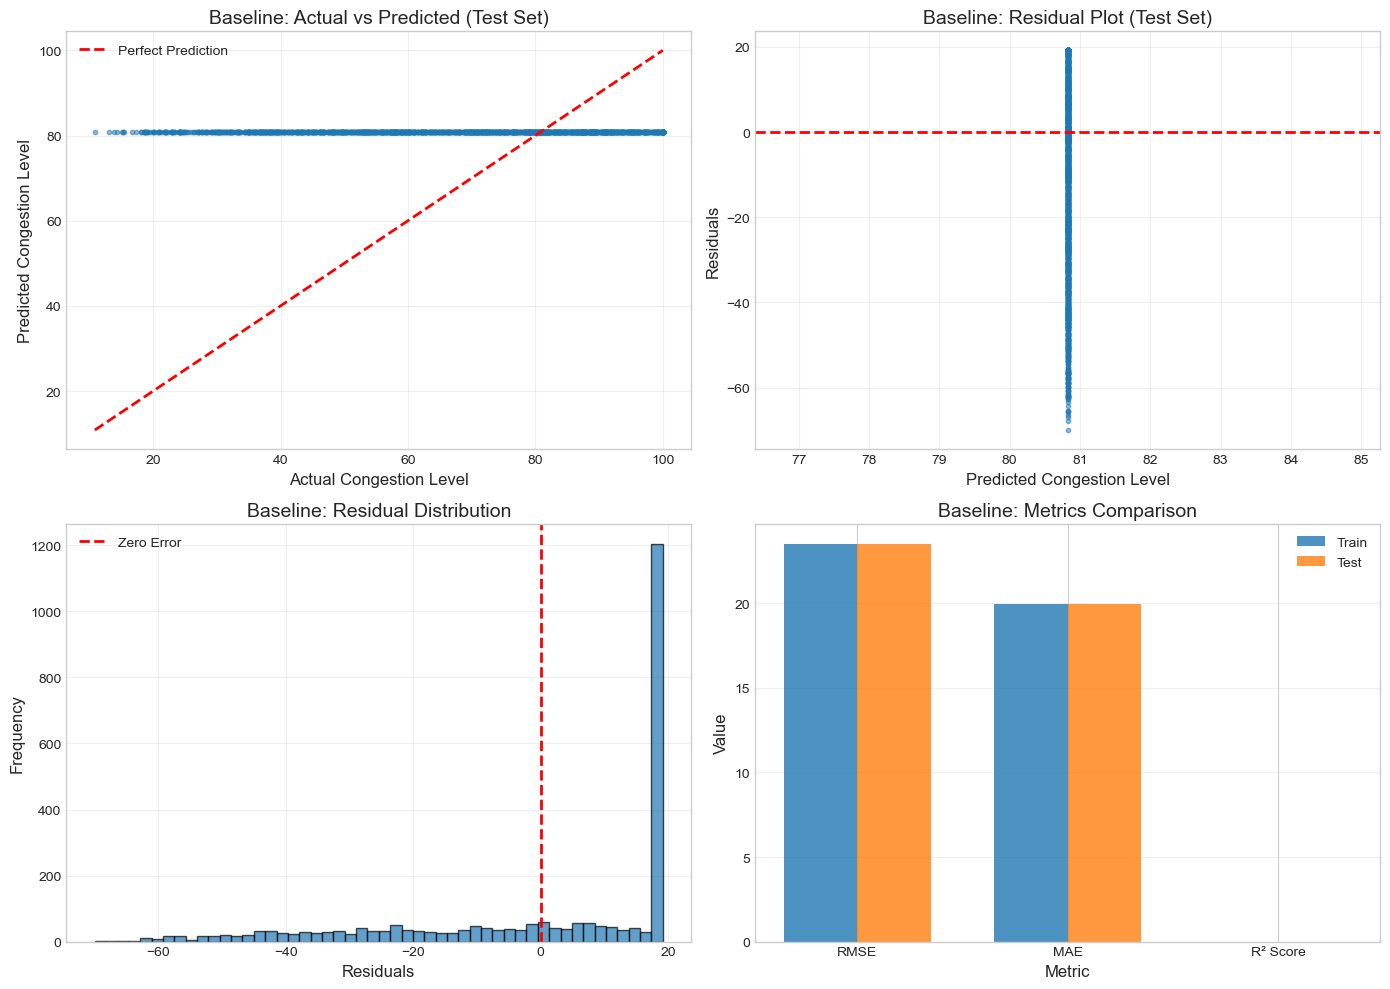

In [19]:
# Visualize predictions vs actual
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted (Test set)
axes[0, 0].scatter(y_test, y_test_pred_baseline, alpha=0.5, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Congestion Level', fontsize=12)
axes[0, 0].set_ylabel('Predicted Congestion Level', fontsize=12)
axes[0, 0].set_title('Baseline: Actual vs Predicted (Test Set)', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residuals (Test set)
residuals = y_test - y_test_pred_baseline
axes[0, 1].scatter(y_test_pred_baseline, residuals, alpha=0.5, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Congestion Level', fontsize=12)
axes[0, 1].set_ylabel('Residuals', fontsize=12)
axes[0, 1].set_title('Baseline: Residual Plot (Test Set)', fontsize=14)
axes[0, 1].grid(alpha=0.3)

# Plot 3: Distribution of residuals
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1, 0].set_xlabel('Residuals', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Baseline: Residual Distribution', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Metrics comparison
x_pos = np.arange(len(metrics_df))
width = 0.35
axes[1, 1].bar(x_pos - width/2, metrics_df['Train'], width, label='Train', alpha=0.8)
axes[1, 1].bar(x_pos + width/2, metrics_df['Test'], width, label='Test', alpha=0.8)
axes[1, 1].set_xlabel('Metric', fontsize=12)
axes[1, 1].set_ylabel('Value', fontsize=12)
axes[1, 1].set_title('Baseline: Metrics Comparison', fontsize=14)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metrics_df['Metric'])
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [20]:
# Additional analysis: Error by congestion level bins
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred_baseline,
    'Error': residuals.values,
    'Abs_Error': np.abs(residuals.values)
})

# Create congestion level bins
test_results['Congestion_Bin'] = pd.cut(test_results['Actual'], 
                                         bins=[0, 25, 50, 75, 100],
                                         labels=['Low (0-25)', 'Medium (25-50)', 'High (50-75)', 'Very High (75-100)'])

# Calculate MAE by bin
mae_by_bin = test_results.groupby('Congestion_Bin')['Abs_Error'].mean().sort_values()

print("\nMean Absolute Error by Congestion Level:")
print("=" * 60)
for bin_name, mae_val in mae_by_bin.items():
    count = (test_results['Congestion_Bin'] == bin_name).sum()
    print(f"{bin_name:20s}: MAE = {mae_val:6.2f} (n={count:,})")
print("=" * 60)


Mean Absolute Error by Congestion Level:
Very High (75-100)  : MAE =  15.15 (n=1,779)
High (50-75)        : MAE =  18.10 (n=482)
Medium (25-50)      : MAE =  41.48 (n=326)
Low (0-25)          : MAE =  60.07 (n=61)


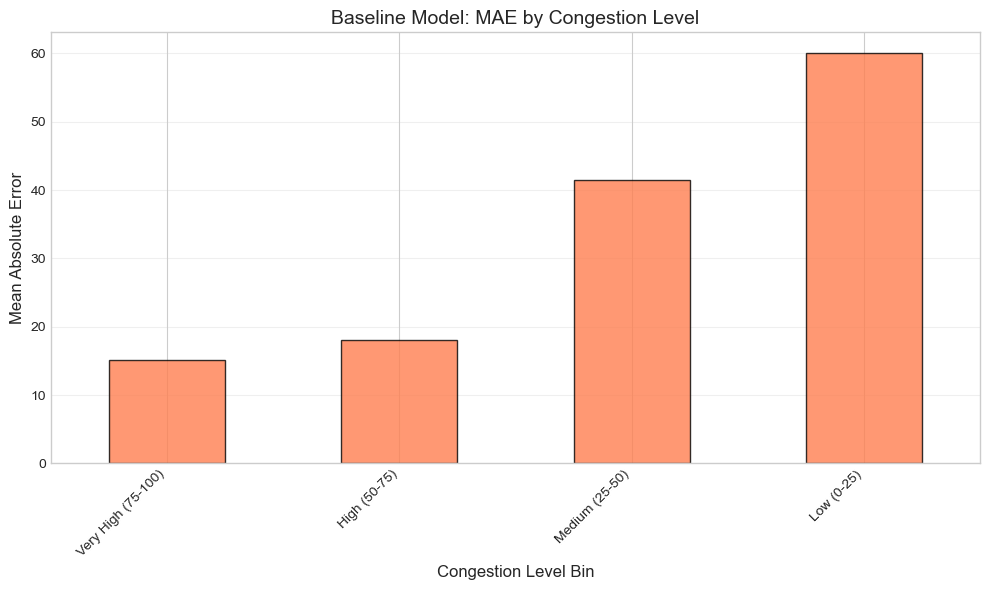

In [21]:
# Visualize error by congestion bin
fig, ax = plt.subplots(figsize=(10, 6))
mae_by_bin.plot(kind='bar', ax=ax, color='coral', edgecolor='black', alpha=0.8)
ax.set_title('Baseline Model: MAE by Congestion Level', fontsize=14)
ax.set_xlabel('Congestion Level Bin', fontsize=12)
ax.set_ylabel('Mean Absolute Error', fontsize=12)
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Summary and Next Steps <a id='7-summary-and-next-steps'></a>

In [22]:
# Save baseline results for comparison
baseline_results = {
    'model_name': 'DummyRegressor (mean)',
    'train_rmse': train_metrics['RMSE'],
    'train_mae': train_metrics['MAE'],
    'train_r2': train_metrics['R² Score'],
    'test_rmse': test_metrics['RMSE'],
    'test_mae': test_metrics['MAE'],
    'test_r2': test_metrics['R² Score']
}

# Save to CSV
results_df = pd.DataFrame([baseline_results])
results_df.to_csv('../models/baseline_results.csv', index=False)
print("Baseline results saved to: ../models/baseline_results.csv")

Baseline results saved to: ../models/baseline_results.csv


### Key Findings

**Baseline Model Performance:**
- The DummyRegressor (mean strategy) predicts the training mean for all samples
- R² Score ≈ 0 indicates the model explains no variance (as expected for a naive baseline)
- RMSE and MAE provide benchmarks that sophisticated models should significantly beat

**Preprocessing Pipeline:**
- Successfully implemented StandardScaler for numerical features
- OneHotEncoder for categorical features (drop_first=True to avoid multicollinearity)
- Fitted on training data only to prevent data leakage

**Temporal Split:**
- 70% training data (earlier dates)
- 30% test data (later dates)
- Simulates real-world prediction scenario

### Next Steps

1. **Implement XGBoost Regressor** as the primary model
2. **Hyperparameter tuning** using GridSearchCV or RandomizedSearchCV
3. **Feature importance analysis** to identify key predictors
4. **Cross-validation** with TimeSeriesSplit for robust evaluation
5. **Model comparison** against baseline
6. **Error analysis** to understand model weaknesses
7. **Deploy best model** for route optimization

### Baseline Metrics to Beat

Any sophisticated model should achieve:
- **RMSE** < Baseline RMSE
- **MAE** < Baseline MAE
- **R² Score** > 0.5 (explains >50% of variance)